# BRFSS 1990–2024 EDA

Hugging Face의 `hesscl/quackrfss` Parquet 데이터를 DuckDB로 원격 조회하고, 집계 결과를 Pandas로 점검·시각화합니다.

- 1990–2010: `_FINALWT` (사후층화 방식)
- 2011–2024: `_LLCPWT` (유선·휴대전화 통합, raking 방식)
- 2011년은 조사·가중치 방법이 바뀐 기준선이므로 추세 그래프에 경계선을 표시합니다.
- `GENHLTH_lbl` 결측은 건강상태 비율 산출에서 제외합니다. 임의 보간한 값을 공식 통계에 사용하지 않습니다.

> 최초 실행은 원격 Parquet 메타데이터와 데이터를 읽으므로 네트워크 상태에 따라 시간이 걸릴 수 있습니다.

In [1]:
import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
sns.set_theme(style="whitegrid", context="notebook")

DATASET_GLOB = "hf://datasets/hesscl/quackrfss/data/BRFSS_*.parquet"
DATASET_2024 = "hf://datasets/hesscl/quackrfss/data/BRFSS_2024.parquet"
con = duckdb.connect()

## 1. 파일 형식과 스키마 확인

각 연도 파일에는 `YEAR`, 원본 숫자 변수, 사람이 읽을 수 있는 `*_lbl` 컬럼이 있습니다. 연도마다 설문 문항이 달라 컬럼 집합도 다르므로 여러 파일을 읽을 때 `union_by_name = true`가 필요합니다.

In [2]:
schema_2024 = con.sql(f"""
    DESCRIBE SELECT * FROM read_parquet('{DATASET_2024}')
""").df()

important_pattern = r"YEAR|GENHLTH|LLCPWT|FINALWT|AGE80|BMI5|MENTHLTH|PHYSHLTH|STATE|STSTR|PSU"
important_schema = schema_2024.loc[
    schema_2024["column_name"].str.contains(important_pattern, case=False, regex=True),
    ["column_name", "column_type", "null"],
]
display(important_schema.reset_index(drop=True))

,column_name,column_type,null
0,YEAR,SMALLINT,YES
1,_STATE,FLOAT,YES
2,_STATE_lbl,VARCHAR,YES
3,IYEAR,VARCHAR,YES
4,_PSU,FLOAT,YES
5,STATERE1,FLOAT,YES
6,CSTATE1,FLOAT,YES
7,GENHLTH,FLOAT,YES
8,GENHLTH_lbl,VARCHAR,YES
9,PHYSHLTH,FLOAT,YES


## 2. 연도별 결측률과 가중 건강상태 비율

전체 원자료를 Pandas로 가져오지 않고 DuckDB에서 연도별로 집계합니다. `Fair`와 `Poor`는 초기 연도에 대문자로 저장된 경우가 있어 `UPPER(TRIM(...))`으로 정규화합니다.

In [ ]:
annual = con.sql(f"""
    WITH normalized AS (
        SELECT
            YEAR,
            UPPER(TRIM(GENHLTH_lbl)) AS genhlth,
            CASE
                WHEN YEAR <= 2010 THEN _FINALWT
                ELSE _LLCPWT
            END AS survey_weight
        FROM read_parquet('{DATASET_GLOB}', union_by_name = true)
    )
    SELECT
        YEAR,
        COUNT(*) AS sample_n,
        COUNT(genhlth) AS genhlth_nonmissing_n,
        COUNT(*) FILTER (WHERE genhlth IN ('FAIR', 'POOR')) AS fair_poor_n,
        SUM(survey_weight) FILTER (
            WHERE genhlth IS NOT NULL AND survey_weight > 0
        ) AS weighted_valid_n,
        SUM(survey_weight) FILTER (
            WHERE genhlth IN ('FAIR', 'POOR') AND survey_weight > 0
        ) AS weighted_fair_poor_n
    FROM normalized
    GROUP BY YEAR
    ORDER BY YEAR
""").df()

annual["genhlth_missing_n"] = annual["sample_n"] - annual["genhlth_nonmissing_n"]
annual["pct_genhlth_missing"] = 100 * annual["genhlth_missing_n"] / annual["sample_n"]
annual["pct_fair_poor_unweighted"] = np.where(
    annual["genhlth_nonmissing_n"] > 0,
    100 * annual["fair_poor_n"] / annual["genhlth_nonmissing_n"],
    np.nan,
)
annual["pct_fair_poor_weighted"] = np.where(
    annual["weighted_valid_n"] > 0,
    100 * annual["weighted_fair_poor_n"] / annual["weighted_valid_n"],
    np.nan,
)

display(annual.round(2))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

### Pandas 기본 점검 명령어

아래 셀에서 `head`, `info`, `describe`, `dtypes`, `isna`를 한 번에 확인합니다.

In [4]:
display(annual.head())
annual.info()
display(annual.describe(include="all").T)
display(annual.dtypes.rename("dtype").to_frame())
display(annual.isna().sum().rename("missing_n").to_frame())

years_without_genhlth = annual.loc[
    annual["genhlth_nonmissing_n"].eq(0), "YEAR"
].tolist()
print("GENHLTH_lbl을 분석할 수 없는 연도:", years_without_genhlth)

,YEAR,sample_n,genhlth_nonmissing_n,fair_poor_n,weighted_valid_n,weighted_fair_poor_n,genhlth_missing_n,pct_genhlth_missing,pct_fair_poor_unweighted,pct_fair_poor_weighted
0,1990,81557,0,0,NaN,NaN,81557,100.00,NaN,NaN
1,1991,87846,0,0,NaN,NaN,87846,100.00,NaN,NaN
2,1992,96213,0,0,NaN,NaN,96213,100.00,NaN,NaN
3,1993,102263,102024,14633,"188,361,286.36","25,234,416.87",239,0.23,14.34,13.40
4,1994,105853,105632,15342,"188,092,755.66","25,740,520.63",221,0.21,14.52,13.69


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35 entries, 0 to 34
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   YEAR                      35 non-null     int16  
 1   sample_n                  35 non-null     int64  
 2   genhlth_nonmissing_n      35 non-null     int64  
 3   fair_poor_n               35 non-null     int64  
 4   weighted_valid_n          26 non-null     float64
 5   weighted_fair_poor_n      26 non-null     float64
 6   genhlth_missing_n         35 non-null     int64  
 7   pct_genhlth_missing       35 non-null     float64
 8   pct_fair_poor_unweighted  26 non-null     float64
 9   pct_fair_poor_weighted    26 non-null     float64
dtypes: float64(5), int16(1), int64(4)
memory usage: 2.7 KB


,count,mean,std,min,25%,50%,75%,max
YEAR,35.00,"2,007.00",10.25,"1,990.00","1,998.50","2,007.00","2,015.50","2,024.00"
sample_n,35.00,"318,853.29","151,095.02","81,557.00","154,665.50","401,958.00","443,294.00","506,467.00"
genhlth_nonmissing_n,35.00,"272,923.60","200,129.52",0.00,"51,012.00","400,997.00","442,071.50","504,455.00"
fair_poor_n,35.00,"50,699.63","38,788.71",0.00,"7,316.50","66,378.00","83,675.00","98,970.00"
weighted_valid_n,26.00,"234,388,717.74","23,553,029.28","188,092,755.66","222,258,462.65","239,580,924.15","252,967,485.61","263,996,909.92"
weighted_fair_poor_n,26.00,"39,696,856.84","7,615,696.91","25,234,416.87","36,530,796.84","39,208,199.57","45,276,874.38","51,479,880.00"
genhlth_missing_n,35.00,"45,929.69","88,321.47",221.00,"1,095.00","1,359.00","41,993.00","356,112.00"
pct_genhlth_missing,35.00,25.95,44.21,0.21,0.26,0.33,50.28,100.00
pct_fair_poor_unweighted,26.00,17.95,1.99,14.34,16.78,18.89,19.38,20.13
pct_fair_poor_weighted,26.00,16.79,1.81,13.40,16.15,16.58,18.14,19.58


,dtype
YEAR,int16
sample_n,int64
genhlth_nonmissing_n,int64
fair_poor_n,int64
weighted_valid_n,float64
weighted_fair_poor_n,float64
genhlth_missing_n,int64
pct_genhlth_missing,float64
pct_fair_poor_unweighted,float64
pct_fair_poor_weighted,float64


,missing_n
YEAR,0
sample_n,0
genhlth_nonmissing_n,0
fair_poor_n,0
weighted_valid_n,9
weighted_fair_poor_n,9
genhlth_missing_n,0
pct_genhlth_missing,0
pct_fair_poor_unweighted,9
pct_fair_poor_weighted,9


GENHLTH_lbl을 분석할 수 없는 연도: [1990, 1991, 1992, 1998, 1999, 2000, 2001, 2002, 2005]


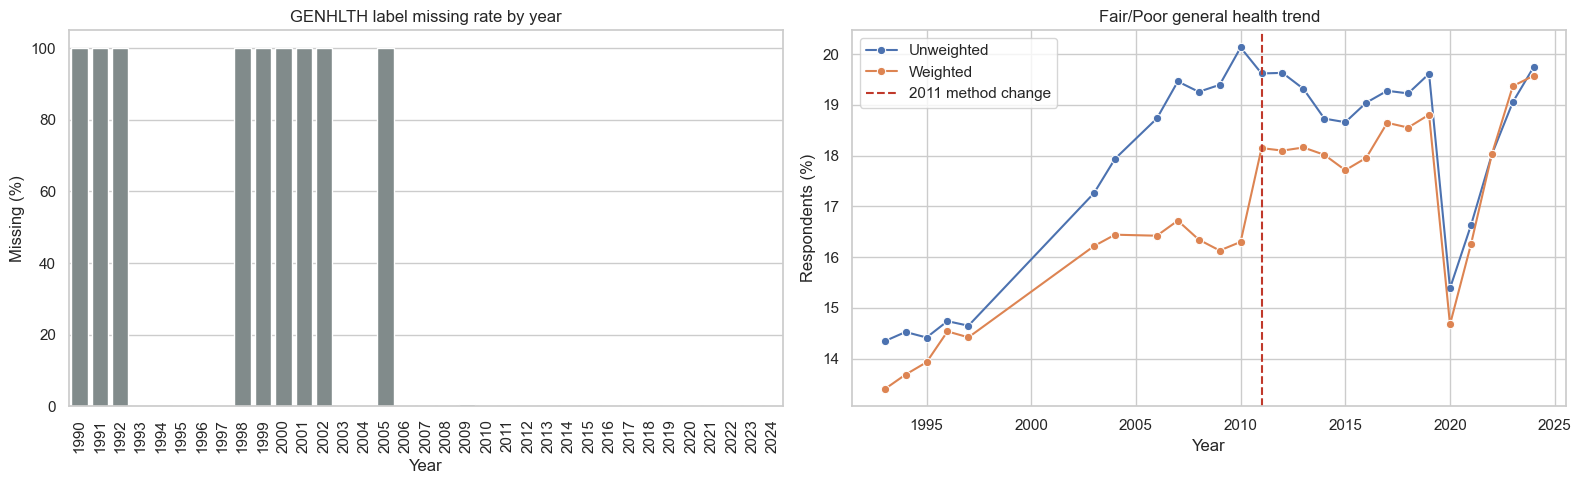

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.barplot(data=annual, x="YEAR", y="pct_genhlth_missing", color="#7F8C8D", ax=axes[0])
axes[0].set(title="GENHLTH label missing rate by year", xlabel="Year", ylabel="Missing (%)")
axes[0].tick_params(axis="x", rotation=90)

trend = annual.dropna(subset=["pct_fair_poor_weighted"])
sns.lineplot(data=trend, x="YEAR", y="pct_fair_poor_unweighted", marker="o", label="Unweighted", ax=axes[1])
sns.lineplot(data=trend, x="YEAR", y="pct_fair_poor_weighted", marker="o", label="Weighted", ax=axes[1])
axes[1].axvline(2011, color="#C0392B", linestyle="--", linewidth=1.5, label="2011 method change")
axes[1].set(title="Fair/Poor general health trend", xlabel="Year", ylabel="Respondents (%)")
axes[1].legend()

plt.tight_layout()
plt.show()

## 3. 2024년 건강상태 분포

표본 비율과 `_LLCPWT` 가중 비율을 함께 비교합니다.

,genhlth,sample_n,weighted_n,unweighted_pct,weighted_pct
0,EXCELLENT,64217,"40,541,383.75",14.07,15.42
1,VERY GOOD,145791,"80,207,882.85",31.95,30.50
2,GOOD,156229,"90,742,581.18",34.23,34.51
4,FAIR,67919,"39,362,754.25",14.88,14.97
3,POOR,22204,"12,117,125.76",4.87,4.61


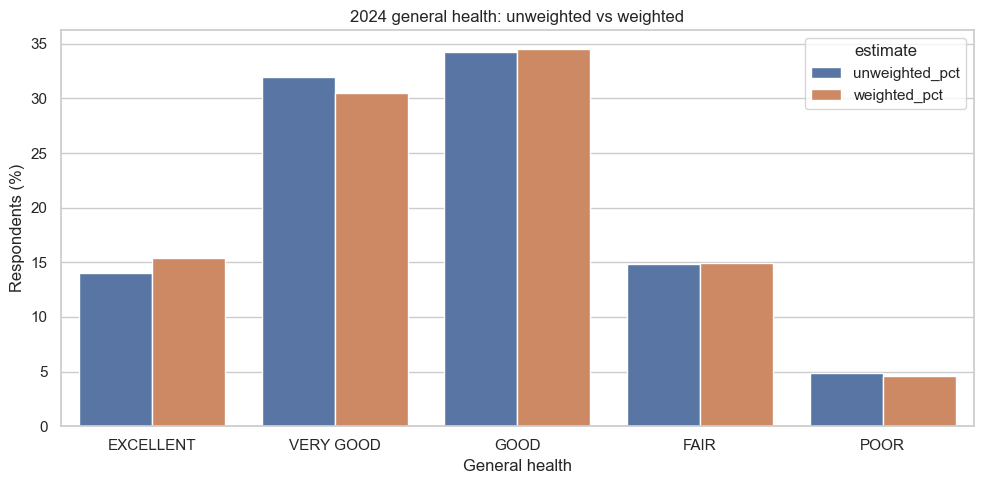

In [6]:
category_2024 = con.sql(f"""
    SELECT
        UPPER(TRIM(GENHLTH_lbl)) AS genhlth,
        COUNT(*) AS sample_n,
        SUM(_LLCPWT) AS weighted_n
    FROM read_parquet('{DATASET_2024}')
    WHERE GENHLTH_lbl IS NOT NULL AND _LLCPWT > 0
    GROUP BY 1
""").df()

category_2024["unweighted_pct"] = 100 * category_2024["sample_n"] / category_2024["sample_n"].sum()
category_2024["weighted_pct"] = 100 * category_2024["weighted_n"] / category_2024["weighted_n"].sum()
health_order = ["EXCELLENT", "VERY GOOD", "GOOD", "FAIR", "POOR"]
category_2024["genhlth"] = pd.Categorical(category_2024["genhlth"], categories=health_order, ordered=True)
category_2024 = category_2024.sort_values("genhlth")
display(category_2024.round(2))

plot_2024 = category_2024.melt(
    id_vars="genhlth",
    value_vars=["unweighted_pct", "weighted_pct"],
    var_name="estimate",
    value_name="percent",
)
plt.figure(figsize=(10, 5))
sns.barplot(data=plot_2024, x="genhlth", y="percent", hue="estimate")
plt.title("2024 general health: unweighted vs weighted")
plt.xlabel("General health")
plt.ylabel("Respondents (%)")
plt.tight_layout()
plt.show()

## 4. 2024년 상세 표본과 결측치 처리

상세 EDA는 메모리를 과도하게 사용하지 않도록 재현 가능한 5만 행 reservoir 표본을 사용합니다.

BRFSS 원시 숫자 변수의 특수 응답 코드도 먼저 처리합니다. `MENTHLTH`와 `PHYSHLTH`에서 `88`은 0일, `77`과 `99`는 결측으로 변환합니다. `_BMI5`는 100으로 나누어 BMI 단위로 바꿉니다.

In [7]:
sample_2024 = con.sql(f"""
    SELECT
        YEAR,
        _STATE_lbl AS state,
        UPPER(TRIM(GENHLTH_lbl)) AS genhlth,
        CASE
            WHEN MENTHLTH BETWEEN 1 AND 30 THEN MENTHLTH
            WHEN MENTHLTH = 88 THEN 0
            ELSE NULL
        END AS poor_mental_days,
        CASE
            WHEN PHYSHLTH BETWEEN 1 AND 30 THEN PHYSHLTH
            WHEN PHYSHLTH = 88 THEN 0
            ELSE NULL
        END AS poor_physical_days,
        _AGE80 AS age,
        CASE
            WHEN _BMI5 BETWEEN 1000 AND 9998 THEN _BMI5 / 100.0
            ELSE NULL
        END AS bmi,
        _LLCPWT AS survey_weight
    FROM read_parquet('{DATASET_2024}')
    USING SAMPLE reservoir(50000 ROWS) REPEATABLE(42)
""").df()

display(sample_2024.head())
sample_2024.info()
display(sample_2024.describe(include="all").T)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,YEAR,state,genhlth,poor_mental_days,poor_physical_days,age,bmi,survey_weight
0,2024,Maryland,VERY GOOD,30.00,0.00,69.00,19.31,55.73
1,2024,Mississippi,GOOD,20.00,0.00,21.00,21.79,924.47
2,2024,Georgia,FAIR,6.00,14.00,55.00,43.05,"1,075.39"
3,2024,Wisconsin,EXCELLENT,0.00,0.00,52.00,23.67,636.63
4,2024,Kansas,GOOD,0.00,0.00,67.00,26.45,228.42


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   YEAR                50000 non-null  int16  
 1   state               49204 non-null  object 
 2   genhlth             49861 non-null  object 
 3   poor_mental_days    49113 non-null  float32
 4   poor_physical_days  48759 non-null  float32
 5   age                 50000 non-null  float32
 6   bmi                 45392 non-null  float32
 7   survey_weight       50000 non-null  float32
dtypes: float32(5), int16(1), object(2)
memory usage: 1.8+ MB


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
YEAR,"50,000.00",NaN,NaN,NaN,"2,024.00",0.00,"2,024.00","2,024.00","2,024.00","2,024.00","2,024.00"
state,49204,52,New York,4890,NaN,NaN,NaN,NaN,NaN,NaN,NaN
genhlth,49861,5,GOOD,17021,NaN,NaN,NaN,NaN,NaN,NaN,NaN
poor_mental_days,"49,113.00",NaN,NaN,NaN,4.46,8.38,0.00,0.00,0.00,5.00,30.00
poor_physical_days,"48,759.00",NaN,NaN,NaN,4.58,8.90,0.00,0.00,0.00,4.00,30.00
age,"50,000.00",NaN,NaN,NaN,54.89,18.17,18.00,40.00,58.00,70.00,80.00
bmi,"45,392.00",NaN,NaN,NaN,28.54,6.54,12.27,24.13,27.44,31.75,96.52
survey_weight,"50,000.00",NaN,NaN,NaN,578.91,"1,191.39",0.01,107.79,263.00,579.59,"35,555.02"


,missing_n,missing_pct
bmi,"4,608.00",9.22
poor_physical_days,"1,241.00",2.48
poor_mental_days,887.00,1.77
state,796.00,1.59
genhlth,139.00,0.28
YEAR,0.00,0.00
age,0.00,0.00
survey_weight,0.00,0.00


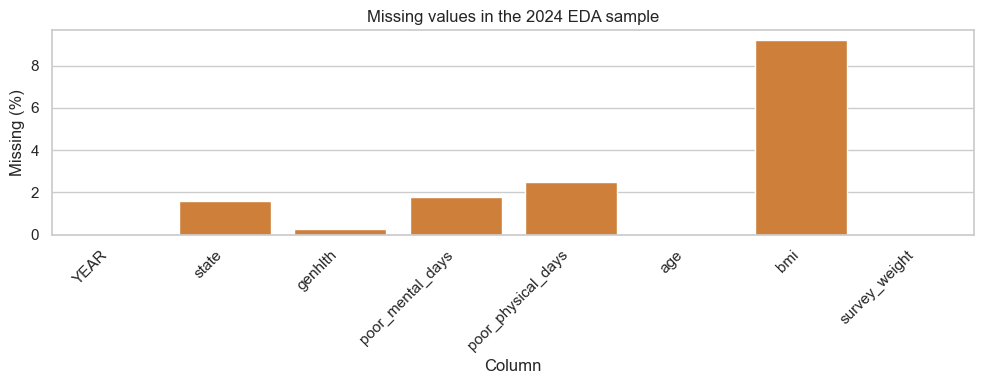

In [8]:
missing_before = (
    sample_2024.isna()
    .agg(["sum", "mean"])
    .T
    .rename(columns={"sum": "missing_n", "mean": "missing_rate"})
)
missing_before["missing_pct"] = 100 * missing_before["missing_rate"]
display(missing_before[["missing_n", "missing_pct"]].sort_values("missing_pct", ascending=False).round(2))

plt.figure(figsize=(10, 4))
sns.barplot(
    data=missing_before.reset_index(),
    x="index",
    y="missing_pct",
    color="#E67E22",
)
plt.title("Missing values in the 2024 EDA sample")
plt.xlabel("Column")
plt.ylabel("Missing (%)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### 탐색용 결측치 보간

원본 `sample_2024`는 변경하지 않고 `eda_imputed` 복사본을 만듭니다.

- BMI: 연령대 중앙값 → 전체 중앙값 순으로 보간
- 정신·신체 건강 불량 일수: 전체 중앙값으로 보간
- 각 숫자 변수에 `*_was_missing` 플래그 추가
- 건강상태와 주 이름은 통계 분석용으로 보간하지 않고, 표시용 컬럼에서만 `UNKNOWN`을 사용

> 보간 데이터는 시각화·모델링 실험용입니다. 가중 유병률, 공식 통계, 보고 수치에는 원래의 유효 응답만 사용하세요.

In [9]:
eda_imputed = sample_2024.copy()
eda_imputed["age_band"] = pd.cut(
    eda_imputed["age"],
    bins=[17, 29, 39, 49, 59, 69, 80],
    labels=["18-29", "30-39", "40-49", "50-59", "60-69", "70-80"],
    include_lowest=True,
)

numeric_to_impute = ["bmi", "poor_mental_days", "poor_physical_days"]
for column in numeric_to_impute:
    eda_imputed[f"{column}_was_missing"] = eda_imputed[column].isna()

bmi_age_median = eda_imputed.groupby("age_band", observed=True)["bmi"].transform("median")
eda_imputed["bmi"] = (
    eda_imputed["bmi"]
    .fillna(bmi_age_median)
    .fillna(eda_imputed["bmi"].median())
)
for column in ["poor_mental_days", "poor_physical_days"]:
    eda_imputed[column] = eda_imputed[column].fillna(eda_imputed[column].median())

eda_imputed["state_for_display"] = eda_imputed["state"].fillna("UNKNOWN")
eda_imputed["genhlth_for_display"] = eda_imputed["genhlth"].fillna("UNKNOWN")

comparison = pd.DataFrame({
    "before_missing_n": sample_2024[numeric_to_impute].isna().sum(),
    "after_missing_n": eda_imputed[numeric_to_impute].isna().sum(),
    "imputed_n": [eda_imputed[f"{c}_was_missing"].sum() for c in numeric_to_impute],
})
display(comparison)
display(eda_imputed.head())

,before_missing_n,after_missing_n,imputed_n
bmi,4608,0,4608
poor_mental_days,887,0,887
poor_physical_days,1241,0,1241


,YEAR,state,genhlth,poor_mental_days,poor_physical_days,age,bmi,survey_weight,age_band,bmi_was_missing,poor_mental_days_was_missing,poor_physical_days_was_missing,state_for_display,genhlth_for_display
0,2024,Maryland,VERY GOOD,30.00,0.00,69.00,19.31,55.73,60-69,False,False,False,Maryland,VERY GOOD
1,2024,Mississippi,GOOD,20.00,0.00,21.00,21.79,924.47,18-29,False,False,False,Mississippi,GOOD
2,2024,Georgia,FAIR,6.00,14.00,55.00,43.05,"1,075.39",50-59,False,False,False,Georgia,FAIR
3,2024,Wisconsin,EXCELLENT,0.00,0.00,52.00,23.67,636.63,50-59,False,False,False,Wisconsin,EXCELLENT
4,2024,Kansas,GOOD,0.00,0.00,67.00,26.45,228.42,60-69,False,False,False,Kansas,GOOD


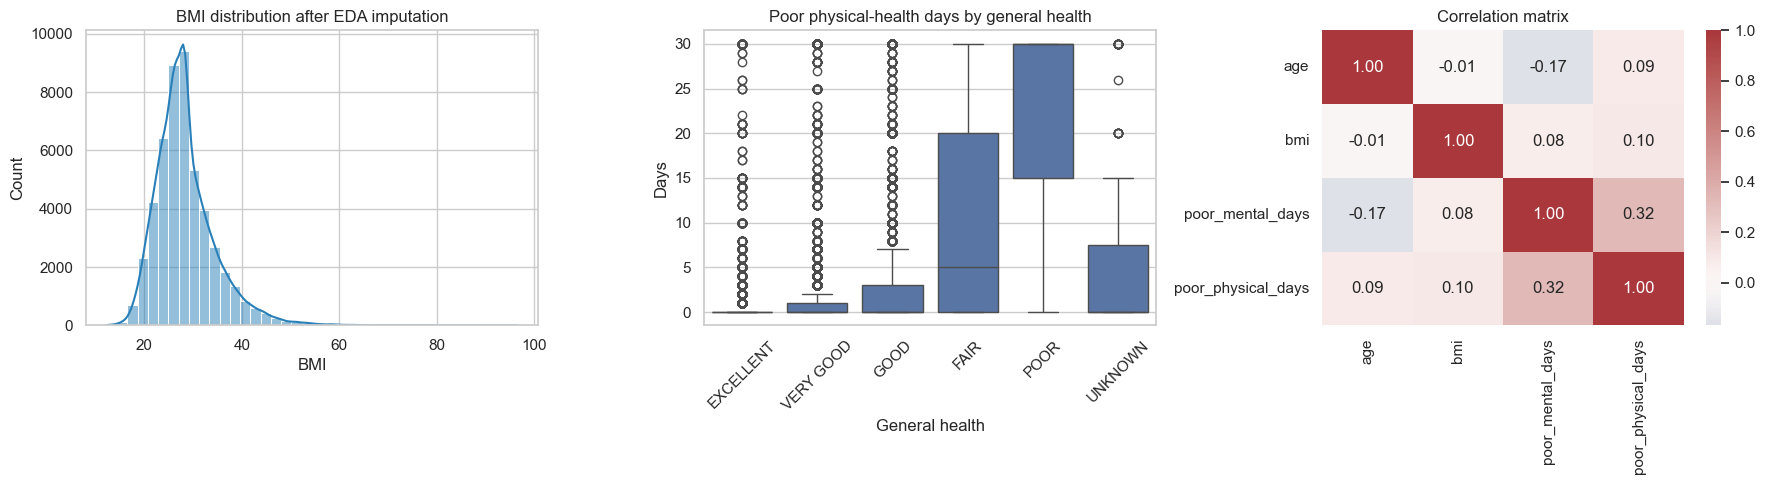

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(data=eda_imputed, x="bmi", bins=40, kde=True, ax=axes[0], color="#2980B9")
axes[0].set(title="BMI distribution after EDA imputation", xlabel="BMI")

sns.boxplot(data=eda_imputed, x="genhlth_for_display", y="poor_physical_days", order=health_order + ["UNKNOWN"], ax=axes[1])
axes[1].set(title="Poor physical-health days by general health", xlabel="General health", ylabel="Days")
axes[1].tick_params(axis="x", rotation=45)

corr_cols = ["age", "bmi", "poor_mental_days", "poor_physical_days"]
sns.heatmap(eda_imputed[corr_cols].corr(), annot=True, fmt=".2f", cmap="vlag", center=0, ax=axes[2])
axes[2].set_title("Correlation matrix")

plt.tight_layout()
plt.show()

## 해석 시 주의사항

1. 2011년 전후 변화에는 실제 건강 변화뿐 아니라 표본 프레임과 가중 방법 변경 효과가 섞여 있습니다.
2. 일부 연도에는 `GENHLTH_lbl` 컬럼 자체가 없으므로 선형 보간으로 연도 값을 만들어서는 안 됩니다.
3. 위의 중앙값 보간은 EDA·모델 실험 예시이며, 공식 비율 산출에는 사용하지 않습니다.
4. 신뢰구간이나 유의성 검정에는 가중치만이 아니라 층화 변수와 PSU를 포함한 복합표본 분석 도구가 필요합니다.
5. 선택 모듈 변수는 `_FINALWT` 또는 `_LLCPWT`가 아니라 별도의 모듈 가중치를 요구할 수 있으므로 연도별 CDC 코드북을 확인해야 합니다.